# 03 Seller Hook Analysis

Goal: identify "hook categories" (first-purchase categories over-indexed among repurchasers) and build a seller governance matrix, then quantify business value (Exposure + ROI sensitivity).\n
This notebook reads from `analysis.analysis_items_atomic`, `analysis.analysis_orders_obt`, `analysis.analysis_user_first_order_categories`, `analysis.analysis_user_rfm`, and raw `Olist.*` tables.

## Section 0: Setup

In [1]:
# ======================================================
# Section 0 (Cell 1/1): Setup
# ======================================================
# Requirements (local):
# - Postgres is running and analysis/raw tables exist
# - DB credentials are provided via env vars (see `.env.example`)
# - Figures will be saved under `outputs/figures/`

import os
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

from sqlalchemy import create_engine

try:
    from dotenv import load_dotenv
except Exception:  # pragma: no cover
    load_dotenv = None

if load_dotenv is not None:
    load_dotenv()

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f'[UTC+8] Run timestamp: {run_ts_utc8}')

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Figures output
figures_dir = project_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
print('Figures will be saved to: /outputs/figures')

# Build engine (prefer DATABASE_URL, fallback to discrete vars)
database_url = os.getenv('DATABASE_URL')
if database_url:
    engine = create_engine(database_url)
else:
    USER = os.getenv('DB_USER')
    PASSWORD = os.getenv('DB_PASS')
    HOST = os.getenv('DB_HOST', 'localhost')
    PORT = os.getenv('DB_PORT', '5432')
    DB = os.getenv('DB_NAME')

    missing = [k for k, v in {'DB_USER': USER, 'DB_PASS': PASSWORD, 'DB_NAME': DB}.items() if not v]
    if missing:
        raise RuntimeError('Missing required env vars (or set DATABASE_URL): ' + ', '.join(missing))

    engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')


[UTC+8] Run timestamp: 2026-02-28 21:47:47 +0800
Figures will be saved to: /outputs/figures


## Section 1: Data Preparation (Atomic Items)

In [2]:
# ======================================================
# Section 1 (Cell 1/1): Data Preparation (Atomic Items)
# ======================================================
# df_items is item-level (atomic) records used for hook + seller analyses.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_items = pd.read_sql('SELECT * FROM analysis.analysis_items_atomic', engine)
print(f'✅ 原子化数据准备完成。行数: {len(df_items)} (比订单数多，因为包含了 Mixed Basket)')
df_items.head()

✅ 原子化数据准备完成。行数: 110189 (比订单数多，因为包含了 Mixed Basket)


,order_id,order_item_id,product_id,seller_id,price,category,review_score,has_review,delay_days,is_late
0,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,pet_shop,4.0,1,-2.330278,0
1,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,furniture_decor,5.0,1,-13.444954,0
2,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,garden_tools,5.0,1,-15.303808,0
3,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,21.90,housewares,4.0,1,-14.427373,0
4,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,19.90,telephony,4.0,1,-16.080810,0


### Section 1 Summary

**Workflow**:
- 读取 `analysis.analysis_items_atomic` 作为后续所有分析的最细粒度输入（Item-grain：`order_id + order_item_id`）。
- 该表把 `seller_id / category / price` 这些供给侧与品类信息，和 `review_score / delay_days / is_late` 这些体验标签对齐到同一行，为后续 hook 与卖家治理提供统一口径。

**Core Figures (from output)**:
- 原子表行数：`110,189`，**大于订单数是预期行为**（Mixed Basket：一个订单多个 item / 多个 seller）。
- 这一步的价值不是“做统计”，而是先把 grain 固化，避免后面做 seller/category 聚合时出现 fan-out 与口径漂移。

**Insights**:
- 在 Olist 这种耐用品平台，“要求用户第二次买同款”会导致样本量崩掉；所以我们后续用 **品类级** 的 hook 定义，而不是 SKU 级复购。
- Mixed Basket 也是后面卖家归因的核心难点：订单晚到不等于某个卖家全责，需要专门的 SLA 解耦（见 Section 4）。

---

## Section 2: Identify Hook Categories (Repurchasers' First Order)

In [3]:
# ======================================================
# Section 2 (Cell 1/1): Identify Hook Categories
# ======================================================
# 钩子:"把用户领进门且留住"的商品,不要求用户第二次必须买同款
# 尤其在Olist这种耐用品为主的平台,"要求同款"会导致样本量归零

# 1. 数据准备
df_rfm = pd.read_sql("SELECT * FROM analysis.analysis_user_rfm", engine)
df_first_order_cats = pd.read_sql("SELECT * FROM analysis.analysis_user_first_order_categories", engine)

# 2. 提取90d窗口复购用户(右删失防御:仅在 eligible 用户上定义)
df_rfm_elig = df_rfm[df_rfm["eligible_repurchase_90d"] == 1].copy()
repurchase_user_ids = df_rfm_elig[df_rfm_elig["repurchase_within_90d"] == 1]["user_id"]
print(f"Eligible users(90d window): {len(df_rfm_elig)}/{len(df_rfm)}")
print(f"90d窗口复购用户总数: {len(repurchase_user_ids)}")

# 3. 提取首单品类信息(user-category 粒度，天然去重)
eligible_user_ids = df_rfm_elig["user_id"]
items_pool = df_first_order_cats[df_first_order_cats["user_id"].isin(eligible_user_ids)]
hook_items_pool = items_pool[items_pool["user_id"].isin(repurchase_user_ids)]

# 4. 统计"钩子"
# acquisition_users / retained_users 都是 distinct users (by construction)
item_counts = items_pool["category"].value_counts()
hook_counts = hook_items_pool["category"].value_counts()

print('\n ["钩子品类"验证结果]')
print(f"复购用户首单包含的(用户,品类)行数: {len(hook_items_pool)}")
#print("Top 10 潜在钩子品类 (按从高到低排序):")
display(
    hook_counts
    .head(10)
)

# 6.根据数据进行决策
# 只有当Top品类的样本量足够大(比如>30),我们才能进行关于"钩子品类"的进一步判断分析
top_1_count = hook_counts.iloc[0] if not hook_counts.empty else 0
top_1_cat = hook_counts.index[0] if not hook_counts.empty else 'N/A'

if top_1_count < 30:
    print(f"\n 样本严重不足! Top 1 品类 ({top_1_cat}) 仅在 {top_1_count} 个复购用户的首单中出现")
    print("结论: 试图从品类维度寻找规律存在巨大的'随机性风险',建议放弃品类分析，转向供给侧(卖家)分析。")
else:
    print(f"\n 初步验证结论:头部样本尚可")

Eligible users(90d window): 75385/93350
90d窗口复购用户总数: 978

 ["钩子品类"验证结果]
复购用户首单包含的(用户,品类)行数: 994


category
bed_bath_table              144
sports_leisure              100
furniture_decor              79
health_beauty                79
watches_gifts                52
housewares                   45
computers_accessories        44
telephony                    41
toys                         39
fashion_bags_accessories     36
Name: count, dtype: int64


 初步验证结论:头部样本尚可


### Section 2 Summary

**Workflow**:
- 从 `analysis.analysis_user_rfm` 取 90d 窗口复购用户：`eligible_repurchase_90d=1` 且 `repurchase_within_90d=1`。
- 直接读取 `analysis.analysis_user_first_order_categories`（(user_id, category) 粒度，首个 delivered 订单的品类集合）。
- 过滤出复购用户的首单品类清单（同一用户同一品类天然去重；一位用户首单可对应多个品类）。

**Core Figures (from output)**:
- 复购用户首单品类 Top10（按出现次数）里，`bed_bath_table / furniture_decor / sports_leisure` 等属于高频耐用品类。
- 但这里的 Top 类别只是“出现次数多”，并不等于“更容易带来复购”（强烈受基准流量影响）。

**Insights**:
- 这一步的真实目的，是把“复购用户首单”这个 cohort 的品类分布抽出来，为下一步计算 **相对复购效率** 做准备。
- 代码里用 `top_1_count < 30` 作为 fail-fast：如果复购样本太小，品类结论会被随机噪声支配，应转向供给侧分析。

**Business Translation**:
- 运营/增长最容易犯的错：只看复购用户首单买了什么（次数），就误判为“钩子品类”。正确做法是看 **复购率（retained/acquisition）**，也就是 Section 3 的矩阵。

---

## Section 3: Hook Category Matrix (Scale vs Efficiency)

Eligible用户90d复购率(基准线): 1.30%
Top 10 高效钩子品类 (按复购率排序):


,retained_users,acquisition_users,retention_rate
category,,,
fashion_bags_accessories,36,1442,2.50%
bed_bath_table,144,7183,2.00%
sports_leisure,100,6070,1.65%
furniture_decor,79,5054,1.56%
pet_shop,18,1193,1.51%
perfumery,32,2482,1.29%
watches_gifts,52,4045,1.29%
health_beauty,79,6203,1.27%
baby,26,2137,1.22%


Saved figure: /outputs/figures/fig_03_hook_category_matrix.png


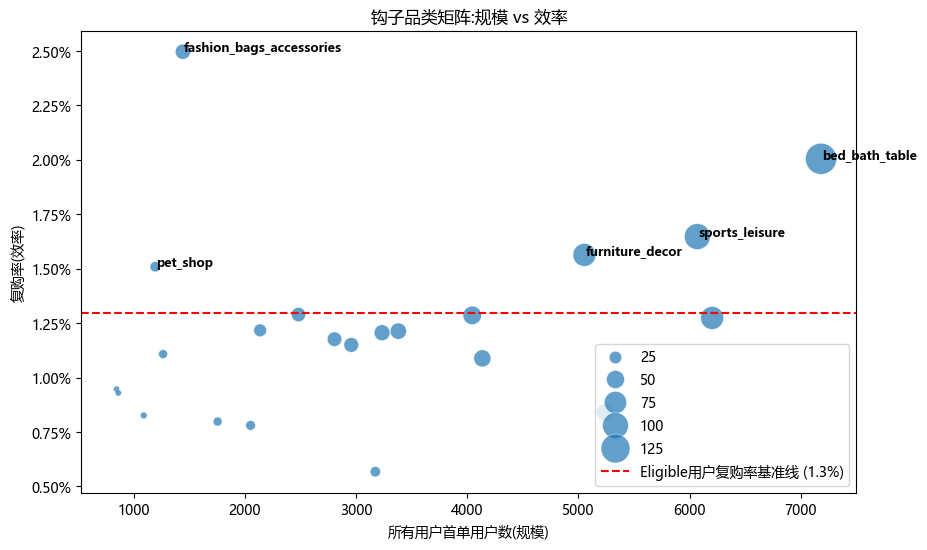

In [4]:
# ======================================================
# Section 3 (Cell 1/1): Hook Category Matrix
# ======================================================
# 逻辑:进一步通过"相对复购效率"来筛选出"钩子品类"

import matplotlib as mpl
from matplotlib.ticker import PercentFormatter

# 保证中文正常显示
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]

# 1. 数据准备
# items_pool:所有用户的首单品类信息
# item_counts:所有用户的首单品类出现次数
# hook_items_pool:复购用户的首单品类信息
# hook_counts:复购用户的首单品类出现次数
acquisition_counts = item_counts.rename("acquisition_users")
retention_counts = hook_counts.rename("retained_users")

# 2. 计算转换率
# concat(...,axis)表示把两张有相同"index"的表按列拼在一起
# 储存每个品类(index)对应的"所有用户首单出现次数","复购用户的首单出现次数"
hook_analysis = (
    pd.concat([acquisition_counts,retention_counts],axis=1)
    .fillna(0)
    .astype({"acquisition_users": "int64", "retained_users": "int64"})
)

# 计算每个品类对应的"复购率"(= "复购用户首单包含该品类的用户数" / "所有用户首单包含该品类的用户数")
hook_analysis["retention_rate"] = hook_analysis["retained_users"].astype("float64") / hook_analysis["acquisition_users"]

# 3. 过滤小样本(只看总获客数 > 500的品类,保证稳健性)
valid_hooks = hook_analysis[hook_analysis["acquisition_users"] > 500].sort_values("retention_rate", ascending=False)

# 4. 计算用户级复购率基准线 (eligible only)
# 基准线 = P(repurchase_within_90d=1 | eligible_repurchase_90d=1)
# 注: 不能用 sum(retained_users)/sum(acquisition_users) 跨品类求和来当用户基准线,因为那是(user,category)对的加权结果
baseline_user = df_rfm_elig["repurchase_within_90d"].mean()

print(f"Eligible用户90d复购率(基准线): {baseline_user:.2%}")
print("Top 10 高效钩子品类 (按复购率排序):")
display(
    valid_hooks[["retained_users","acquisition_users","retention_rate"]]
    .head(10)
    .style.format({"retention_rate":"{:.2%}"})
)

# 5. 可视化:"规模 vs 效率"矩阵
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=valid_hooks,
    x="acquisition_users",
    y="retention_rate", 
    size="retained_users",
    sizes=(20, 500), 
    alpha=0.7
)

# 画基准线
plt.axhline(baseline_user, color="red", linestyle="--", label=f'Eligible用户复购率基准线 ({baseline_user:.1%})')
plt.title('钩子品类矩阵:规模 vs 效率')
plt.xlabel('所有用户首单用户数(规模)')
plt.ylabel('复购率(效率)')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

# 标出 Top 5
for i in range(5):
    row = valid_hooks.iloc[i]
    plt.text(
        row["acquisition_users"]+10, 
        row["retention_rate"], 
        valid_hooks.index[i],
        weight="bold", 
        fontsize=9
    )

fig = plt.gcf()
out_path = figures_dir / 'fig_03_hook_category_matrix.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: /outputs/figures/{out_path.name}")
plt.show()

### Section 3 Summary

**Workflow**:
- 先算每个品类的两件事：
  1) `acquisition_users`：所有用户中，首单包含该品类的用户数（规模）
  2) `retained_users`：复购用户中，首单包含该品类的用户数（留存贡献）
- 用 `retention_rate = retained_users / acquisition_users` 得到品类的相对复购效率。
- 过滤小样本（`acquisition_users > 500`）避免 “高复购率 = 小样本偶然”。

**Core Figures (from output)**:
- Eligible 用户 90d 复购率（用户级基准线）：`1.30%`。
- Top hooks（效率高于大盘且样本量足够，示例 Top5）：
  - `fashion_bags_accessories`: `2.50%`（`36/1442`）
  - `bed_bath_table`: `2.00%`（`144/7183`）
  - `sports_leisure`: `1.65%`（`100/6070`）
  - `furniture_decor`: `1.56%`（`79/5054`）
  - `pet_shop`: `1.51%`（`18/1193`）

**Insights**:
- 这张图是典型的 **规模-效率权衡**：只看效率容易被小样本噪声带偏；只看规模会选到‘大路货’但留存效率一般。
- 泡泡大小（`retained_users`）把‘贡献’可视化：高效率 + 足够 retained 才值得成为增长入口。
- 基准线偏低（1%级别）意味着这更像低频耐用品平台：增长动作更应该围绕‘提升首单质量/体验’而不是盲目做复购刺激。

**Business Translation**:
- **投放/上新策略**：优先围绕高效钩子品类做首单引流（品类页资源、站外投放、优惠券绑定），目标是提升“首单->复购”的 cohort 质量。
- **指标口径**：把 `retention_rate` 当作‘获客质量系数’，而不是只盯首单 GMV。

**Artifacts**:
- 已保存图表: `/outputs/figures/fig_03_hook_category_matrix.png`

---

## Section 4: Seller Governance Matrix (GMV vs SLA Gap)


[供给侧分析数据]
总活跃卖家(订单数大于30): 611
需要处理的恶劣卖家数: 58 (占比 9.5%)
恶劣卖家贡献的违约单比例: 15.4% (帕累托效应)
Saved figure: /outputs/figures/fig_03_seller_governance_matrix.png


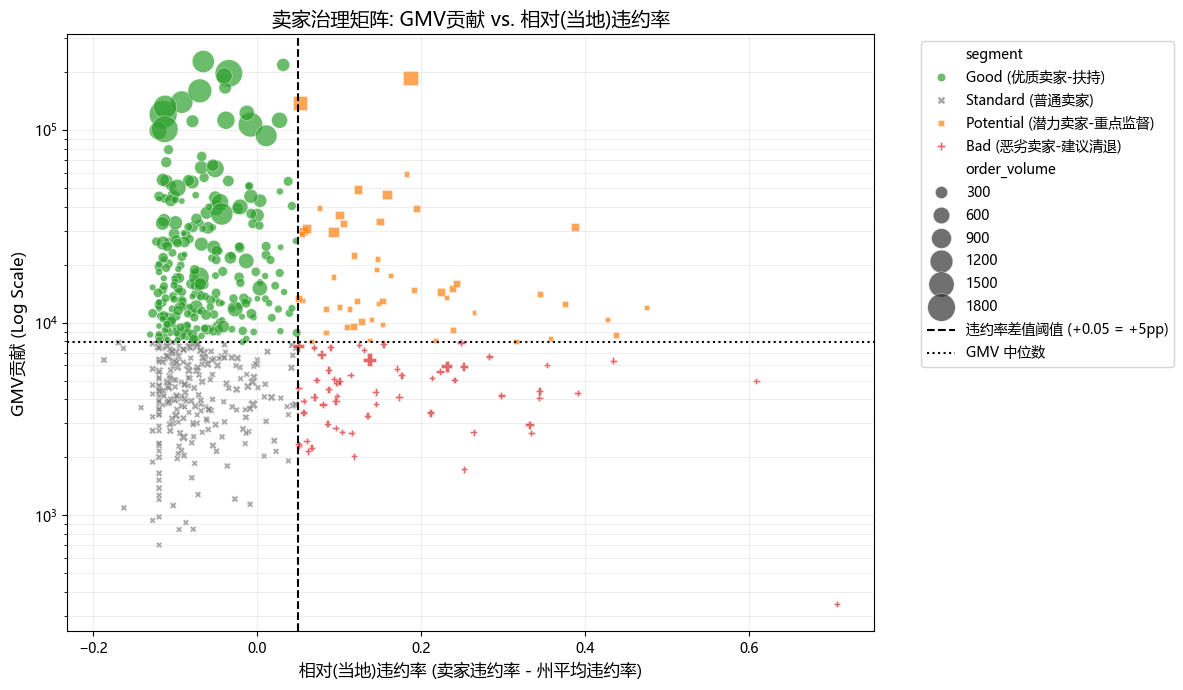

,seller_id,price,sla_breach_rate
segment,,,
Good (优质卖家-扶持),254,"$7,432,127",5.4%
Potential (潜力卖家-重点监督),51,"$1,260,125",29.4%
Standard (普通卖家),248,"$1,119,539",4.3%
Bad (恶劣卖家-建议清退),58,"$263,811",29.6%


In [5]:
# ======================================================
# Section 4 (Cell 1/1): Seller Governance Matrix
# ======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------
# 1. 数据准备与特征工程(归因解耦)
# ------------------------------------------
# 目标: 获取shipping_limit_date(平台规定的商家最迟发货时间--SLA截止时间)
# 注意: 1.同一个订单里面不同商品的卖家不同,同一订单的不同商品最迟发货时间也可能不同
#      2.同一个订单所有商品的实际发货时间是一致的
# Olist.olist_order_items_dataset表记录了每个订单的SLA截止时间
# analysis.analysis_orders_obt表记录了每个订单的实际发货时间

# 读取原始商品详细数据(包括SLA截止时间)
df_raw_items = pd.read_sql(
"""
    SELECT 
        order_id, 
        order_item_id, 
        seller_id, 
        shipping_limit_date::TIMESTAMP AS shipping_limit_date, 
        price::numeric AS price 
    FROM Olist.olist_order_items_dataset
""", engine)

# 读取 OBT 数据 (包含实际发货时间)
df_obt_delivery = pd.read_sql(
"""
    SELECT 
        order_id, 
        carrier_ts AS carrier_date
    FROM analysis.analysis_orders_obt
""", engine)

# 关联数据
df_seller_audit = df_raw_items.merge(df_obt_delivery, on="order_id", how="inner")

# 转换时间类型
df_seller_audit["shipping_limit_date"] = pd.to_datetime(df_seller_audit["shipping_limit_date"])
df_seller_audit["carrier_date"] = pd.to_datetime(df_seller_audit["carrier_date"])

# 核心指标: SLA违约标记(1=违约, 0=守约)
# 逻辑: 卖家发货时间 > 最迟发货时间 = 卖家全责
df_seller_audit["is_sla_breach"] = (df_seller_audit["carrier_date"] > df_seller_audit["shipping_limit_date"]).astype(int)

# ------------------------------------------
# 2. 卖家信息聚合(包含地理信息)
# ------------------------------------------
# 读取卖家地理信息
df_sellers_geo = pd.read_sql("SELECT seller_id, seller_state FROM Olist.olist_sellers_dataset", engine)

# 聚合计算
seller_stats = df_seller_audit.groupby("seller_id").agg({
    
    # 计算卖家参与的不同订单数量
    'order_id': 'nunique',          # 订单量
    'price': 'sum',                 # GMV
    
    # 因为数值为0或1,直接取平均值可以得到违约率
    'is_sla_breach': 'mean'         # 违约率
}).rename(columns={'order_id': 'order_volume', 'is_sla_breach': 'sla_breach_rate'})

# 添加地理信息
seller_stats = seller_stats.merge(df_sellers_geo, on="seller_id", how="left")

# ------------------------------------------
# 3. 相对绩效计算(公平性校准)
# ------------------------------------------
# 计算各州的"平均违约率"作为基准 (用来排除偏远地区揽收难的客观地理因素)
state_benchmark = seller_stats.groupby("seller_state")["sla_breach_rate"].mean().rename("state_avg_breach_rate")

# 添加对应州基准
seller_final = seller_stats.merge(state_benchmark, on='seller_state', how='left')

# 计算Performance Gap(相对违约率 = 卖家违约率 - 当地平均违约率)
# Gap > 0: 比基准慢 (卖家问题)
seller_final["performance_gap"] = seller_final["sla_breach_rate"] - seller_final["state_avg_breach_rate"]

# 过滤长尾 (只看订单量 > 30 的卖家)
main_sellers = seller_final[seller_final["order_volume"] > 30].copy()

# ------------------------------------------
# 4. 策略分层(向量化实现)
# ------------------------------------------
# 计算卖家的总GMV中值,作为划分基线
gmv_threshold = main_sellers["price"].median()

# 设定容忍度:绝对差值 5pp (performance_gap = seller - state_avg)
gap_threshold = 0.05

# 定义条件
cond_lazy = main_sellers["performance_gap"] > gap_threshold
cond_rich = main_sellers["price"] > gmv_threshold

# 定义标签
conditions = [
    (cond_lazy & ~cond_rich),  # 发货慢且贡献小
    (cond_lazy & cond_rich),   # 发货慢且贡献大
    (~cond_lazy & cond_rich),  # 发货快且贡献大
    (~cond_lazy & ~cond_rich)  # 发货快且贡献小 (长尾)
]
choices = [
    'Bad (恶劣卖家-建议清退)', 
    'Potential (潜力卖家-重点监督)', 
    'Good (优质卖家-扶持)', 
    'Standard (普通卖家)'
]

main_sellers["segment"] = np.select(conditions, choices, default="Standard")

# ------------------------------------------
# 5. 帕累托集中度分析
# ------------------------------------------
# 目标: 计算劣质卖家造成的危害集中度

# 提取"劣质卖家"
bad_sellers = main_sellers[main_sellers["segment"].isin(['Bad (恶劣卖家-建议清退)'])]

# "劣质卖家"的违约单量 = "劣质卖家"订单数 × "劣质卖家"总平均违约率
# Expected breached orders contributed by bad sellers (order-weighted)
bad_orders = (bad_sellers["order_volume"] * bad_sellers["sla_breach_rate"]).sum()

# 总期望违约单量 = 每个卖家的违约单量再加和
# 每个卖家的违约单量 = 订单数 × 总平均违约率
total_breach_orders = (main_sellers["order_volume"] * main_sellers["sla_breach_rate"]).sum()

# "劣质卖家"违约单占比 = "劣质卖家"违约单量 / 总违约单量
concentration_ratio = bad_orders / total_breach_orders if total_breach_orders > 0 else 0

print(f"\n[供给侧分析数据]")
print(f"总活跃卖家(订单数大于30): {len(main_sellers)}")
print(f"需要处理的恶劣卖家数: {len(bad_sellers)} (占比 {len(bad_sellers)/len(main_sellers):.1%})")
print(f"恶劣卖家贡献的违约单比例: {concentration_ratio:.1%} (帕累托效应)")

# ------------------------------------------
# Step 6: 数据可视化 (治理矩阵)
# ------------------------------------------
# 绘制散点图,对各类卖家分层可视化
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=main_sellers, 
    # x轴为相对(当地)违约率
    x="performance_gap", 
    # y轴为卖家贡献的总GMV
    y="price", 
    hue="segment", 
    style="segment",
    palette={'Bad (恶劣卖家-建议清退)': '#d62728', 'Potential (潜力卖家-重点监督)': '#ff7f0e', 
             'Good (优质卖家-扶持)': '#2ca02c', 'Standard (普通卖家)': 'grey'},
    size="order_volume", 
    sizes=(20, 400), 
    alpha=0.7
)

# 辅助线
plt.axvline(gap_threshold, color='black', linestyle='--', label=f'违约率差值阈值 (+{gap_threshold:.2f} = +5pp)')
plt.axhline(gmv_threshold, color='black', linestyle=':', label='GMV 中位数')

# 标注
plt.title('卖家治理矩阵: GMV贡献 vs. 相对(当地)违约率', fontsize=14)
plt.xlabel('相对(当地)违约率 (卖家违约率 - 州平均违约率)', fontsize=12)
plt.ylabel('GMV贡献 (Log Scale)', fontsize=12)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
fig = plt.gcf()
out_path = figures_dir / 'fig_03_seller_governance_matrix.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: /outputs/figures/{out_path.name}")
plt.show()

# 输出分层统计表
display(main_sellers.groupby("segment").agg({
    'seller_id': 'count',
    'price': 'sum',
    'sla_breach_rate': 'mean'
}).sort_values('price', ascending=False).style.format({
    'price': '${:,.0f}', 
    'sla_breach_rate': '{:.1%}'
}))


### Section 4 Summary

**Workflow**:
- 用 `shipping_limit_date`（卖家承诺的最迟发货时间）与 `carrier_date`（实际交接给承运商时间）构造 `is_sla_breach`，完成 **卖家责任解耦**。
- 聚合到 seller 粒度：`order_volume`（订单数）、`price`（GMV）、`sla_breach_rate`（违约率）。
- 做公平性校准：在 `seller_state` 维度计算基准违约率，得到 `performance_gap = seller - state_avg`。
- 过滤长尾（`order_volume > 30`）后构建治理矩阵：`GMV 贡献` x `相对违约率`，并做帕累托集中度分析。

**Core Figures (from output)**:
- 总活跃卖家（订单数 > 30）：`611`。
- 需要处理的恶劣卖家：`58`（`9.5%`），但贡献了约 `15.4%` 的违约单（帕累托效应）。
- 分层结果（示例，来自矩阵汇总表）：
  - `Good`: GMV `$7,432,127`, breach `5.4%`
  - `Potential`: GMV `$1,260,125`, breach `29.4%`
  - `Standard`: GMV `$1,119,539`, breach `4.3%`
  - `Bad`: GMV `$263,811`, breach `29.6%`

**Insights**:
- 如果不做 SLA 解耦，平台很容易把‘物流慢’错判成卖家问题或反之，治理会误伤优质卖家。
- `Potential`（高 GMV + 高违约）是最值得治理的象限：不是一刀切清退，而是重点监管/改造，有明显 ROI 空间。

**Business Translation**:
- **治理策略分层**：
  - `Bad`：清退或强约束（限流/保证金/处罚）
  - `Potential`：重点整改（SLA 改善计划、履约考核、履约工具支持）
  - `Good`：扶持（流量倾斜、履约能力扩容）
  - `Standard`：长尾自动化（规则化管理）

**Artifacts**:
- 已保存图表: `/outputs/figures/fig_03_seller_governance_matrix.png`

---

## Section 5: Business Case (Exposure + ROI Sensitivity)


[商业价值核算]
风险敞口(劣质卖家涉及的GMV): 263,811.44
  - 这部分GMV由劣质卖家经手，平均(发货)违约率高达 29.6%
  - 若不治理，这部分营收不仅可能变成低评分订单，甚至可能产生退款,永久伤害用户留存
Saved figure: /outputs/figures/fig_03_roi_sensitivity_heatmap.png


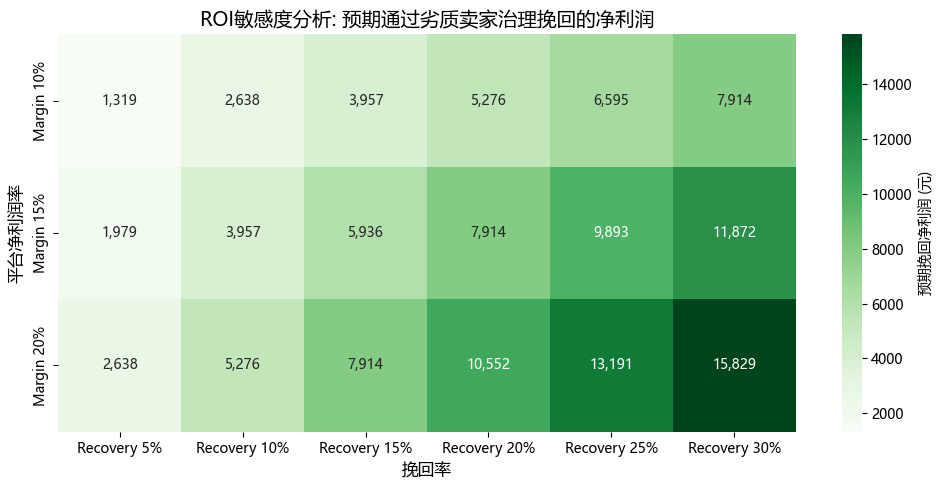


结论: 即使按保守估计( 10% 挽回率, 15% 利润率)
治理劣质卖家预计能直接为平台挽回净利润: 3,957 元
(这仅是直接财务收益，尚未计算用户LTV提升等带来的长期价值)


In [6]:
# ======================================================
# Section 5 (Cell 1/1): Business Case (Exposure + Sensitivity)
# ======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# ----------------------------------------
# 1. 计算风险敞口 (Risk Exposure)
# ----------------------------------------
# 定义: 由"劣质卖家"经手的总GMV (Risk Exposure)
# 逻辑: 只要坏卖家经手,体验/退款/差评/流失的风险上升,因此这部分GMV属于可治理的风险资金池

# 重新筛选出劣质卖家
bad_sellers_list = main_sellers[main_sellers["segment"] == 'Bad (恶劣卖家-建议清退)']["seller_id"]

# 计算劣质卖家涉及的总GMV
# 这里计算total price,代表"劣质卖家能影响的生意规模"
gmv_at_risk = main_sellers[main_sellers["segment"] == 'Bad (恶劣卖家-建议清退)']["price"].sum()

# 计算劣质卖家的违约单占比 (SLA Breach Rate)
bad_breach_rate = main_sellers[main_sellers["segment"] == 'Bad (恶劣卖家-建议清退)']["sla_breach_rate"].mean()

print(f"\n[商业价值核算]")
print(f"风险敞口(劣质卖家涉及的GMV): {gmv_at_risk:,.2f}")
print(f"  - 这部分GMV由劣质卖家经手，平均(发货)违约率高达 {bad_breach_rate:.1%}")
print(f"  - 若不治理，这部分营收不仅可能变成低评分订单，甚至可能产生退款,永久伤害用户留存")

# --------------------------------------------------------
# 2. 敏感性分析
# --------------------------------------------------------
# 逻辑: 不预测单一数值，而是计算在不同"治理成功率"下的收益矩阵
# 探究: 如果将这部分订单转移给优质卖家(或通过治理让劣质卖家变好)，能挽回多少损失？

# 设定情景: 挽回比例 (Recovery Rate) 从 5% 到 30%
recovery_rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
# 设定情景: 净利润率 (Net Margin) - 保守假设平台佣金+广告费约为 15%
# 设定多个利润率方便可视化对比
margin_rates = [0.10, 0.15, 0.20] 

# 构建"不同挽回比例、净利润率组合"的挽回净利润矩阵数据
sensitivity_data = []
for margin in margin_rates:
    # 初始化
    row = []
    for rate in recovery_rates:
        # 挽回的净利润 = 风险GMV * 挽回比例 * 净利润率
        saved_profit = gmv_at_risk * rate * margin
        row.append(saved_profit)
    sensitivity_data.append(row)

# 矩阵数据转为DataFrame用于绘图
df_sensitivity = pd.DataFrame(
    sensitivity_data, 
    index=[f"Margin {m:.0%}" for m in margin_rates], 
    columns=[f"Recovery {r:.0%}" for r in recovery_rates]
)

# --------------------------------------
# 3. 可视化:收益热力图
# --------------------------------------
plt.figure(figsize=(10, 5))
sns.heatmap(df_sensitivity, annot=True, fmt=",.0f", cmap="Greens", cbar_kws={'label': '预期挽回净利润 (元)'})

plt.title('ROI敏感度分析: 预期通过劣质卖家治理挽回的净利润', fontsize=14)
plt.xlabel('挽回率', fontsize=12)
plt.ylabel('平台净利润率', fontsize=12)
plt.tight_layout()
fig = plt.gcf()
out_path = figures_dir / 'fig_03_roi_sensitivity_heatmap.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: /outputs/figures/{out_path.name}")
plt.show()


print("\n结论: 即使按保守估计( 10% 挽回率, 15% 利润率)")
print(f"治理劣质卖家预计能直接为平台挽回净利润: {gmv_at_risk * 0.1 * 0.15:,.0f} 元")
print("(这仅是直接财务收益，尚未计算用户LTV提升等带来的长期价值)")

### Section 5 Summary

**Workflow**:
- 用 **Risk Exposure（风险敞口）** 把治理问题从‘指标好不好看’转成‘平台有多少钱暴露在高风险卖家手里’：`gmv_at_risk`。
- 用敏感性分析替代单点预测：在不同 `recovery_rate` 与 `margin` 假设下，计算可挽回净利润矩阵并可视化。

**Core Figures (from output)**:
- 风险敞口（劣质卖家涉及 GMV）：`263,811.44`。
- 劣质卖家平均 SLA 违约率：`29.6%`。
- 保守情景（`10%` 挽回率、`15%` 净利润率）：预计挽回净利润约 `3,957` 元（仅直接收益）。

**Insights**:
- 这套估算刻意保守：只计算直接财务收益，没有把‘差评/退款减少 -> 留存提升 -> LTV 提升’计入，因此更适合做决策下限。
- 敏感性矩阵能防止拍脑袋：让干系人明确‘ROI 依赖挽回率与利润率’这两个关键假设。

**Business Translation**:
- 把治理项目写成可执行 KPI：例如 1) 把 Bad 卖家占比从 `9.5%` 降到 `6%` 以内；2) 把其 breach rate 从 `29.6%` 拉到州基准附近（例如 `performance_gap <= 5pp`）；3) 用 ROI 矩阵追踪财务回收。

**Artifacts**:
- 已保存图表: `/outputs/figures/fig_03_roi_sensitivity_heatmap.png`

---